In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm

import imageio
import os
import shutil

In [2]:
edges = np.loadtxt("transitions.txt").astype(int)
state_map  = np.loadtxt("state_map.txt", dtype=str, delimiter=",")[1:-1]

In [3]:
edges_df = pd.DataFrame({"from":edges[:,0],"to":edges[:,1],"freq":edges[:,2]})
#edges_df = edges_df[edges_df['from']!=edges_df['to']]#.sort_values("freq")
#edges_df = edges_df[edges_df['to']!=4]

In [4]:
edges_df

,from,to,freq
0,1,4,12
1,2,2,67
2,3,3,30
3,4,9,1
4,5,10,185
...,...,...,...
918,242,242,25
919,4,221,59
920,5,277,1
921,22,22,101


In [5]:
sm_keys = np.array([sm.split(":")[0][1:-1].split("+") for sm in state_map])
sm_vals = [sm.split(":")[1][:] for sm in state_map]
state_df = pd.DataFrame({"idx":np.array(sm_vals).astype(int), "type":sm_keys[:,0], "mut":sm_keys[:,1]})
state_df["nchr"] = state_df["type"].map(lambda x: len(x.split("/")))
state_df["ngenes"] = state_df["type"].map(lambda x: len(("").join(x.split("/"))))
state_df = state_df.sort_values("idx")
state_df = state_df.reset_index(drop=True)
state_df

,idx,type,mut,nchr,ngenes
0,1,1111122111111111/1111111111111111,0000000000000000/0000000000000000,2,32
1,2,1111111111111111/1111111211111111,0000000000000000/0000000000000000,2,32
2,3,1111111111111111/1111111111111111,0000010101000000/0101000010000010,2,32
3,4,1111111111111111/1111111111111111,0000000000000000/0000000000000000,2,32
4,5,1111111111111111/1111111111111111,1111111111111101/1111111111111111,2,32
...,...,...,...,...,...
307,310,1111111111111111/1111111111111111,1011111111111110/1111111111111111,2,32
308,311,1111111111111111/1111111111111111,1111111111101101/1111110010011111,2,32
309,312,1111111111111111/1111111111111111,1101111111111110/1111001110111110,2,32
310,313,1111111111111111/1111111111111111,1111111111101110/1111011110111111,2,32


In [6]:
edge_list = edges_df[["from","to"]].values

g = Graph(directed=True)
g.add_edge_list(edge_list)
g.ep['w'] = g.new_edge_property("int", vals=edges_df["freq"])
g.vp['nchr'] = g.new_vertex_property("int", vals=state_df["nchr"])
g.vp['ng'] = g.new_vertex_property("int", vals=state_df["ngenes"])
#remove_self_loops(g)
g

<Graph object, directed, with 315 vertices and 923 edges, 2 internal vertex properties, 1 internal edge property, at 0x7f0b4bab92b0>

In [7]:
#pos = arf_layout(g)
#pos = fruchterman_reingold_layout(g, r=2)

In [8]:
in_deg = g.degree_property_map("in").a
out_deg = g.degree_property_map("out").a

vsize = g.new_vertex_property("float", vals=np.log(out_deg+1)*10)

esize = g.new_edge_property("float", vals=np.log10(g.ep['w'].a+1)*2)

# Normalize the out-degree values
min_deg = np.min(g.vp['nchr'].a)
max_deg = np.max(g.vp['nchr'].a)
# Avoid division by zero if all degrees are equal
normalize = lambda d: (d - min_deg) / (max_deg - min_deg) if max_deg > min_deg else 0.5

# Create a vertex property map for colors
v_color = g.new_vertex_property("vector<double>")

# Choose a colormap (here we use viridis)
for v, d in zip(g.vertices(), g.vp['nchr'].a):
    norm_val = normalize(d)
    # Get RGB color (ignore alpha) from colormap; values are in the range [0,1]
    v_color[v] = cm.viridis(norm_val)[:3]

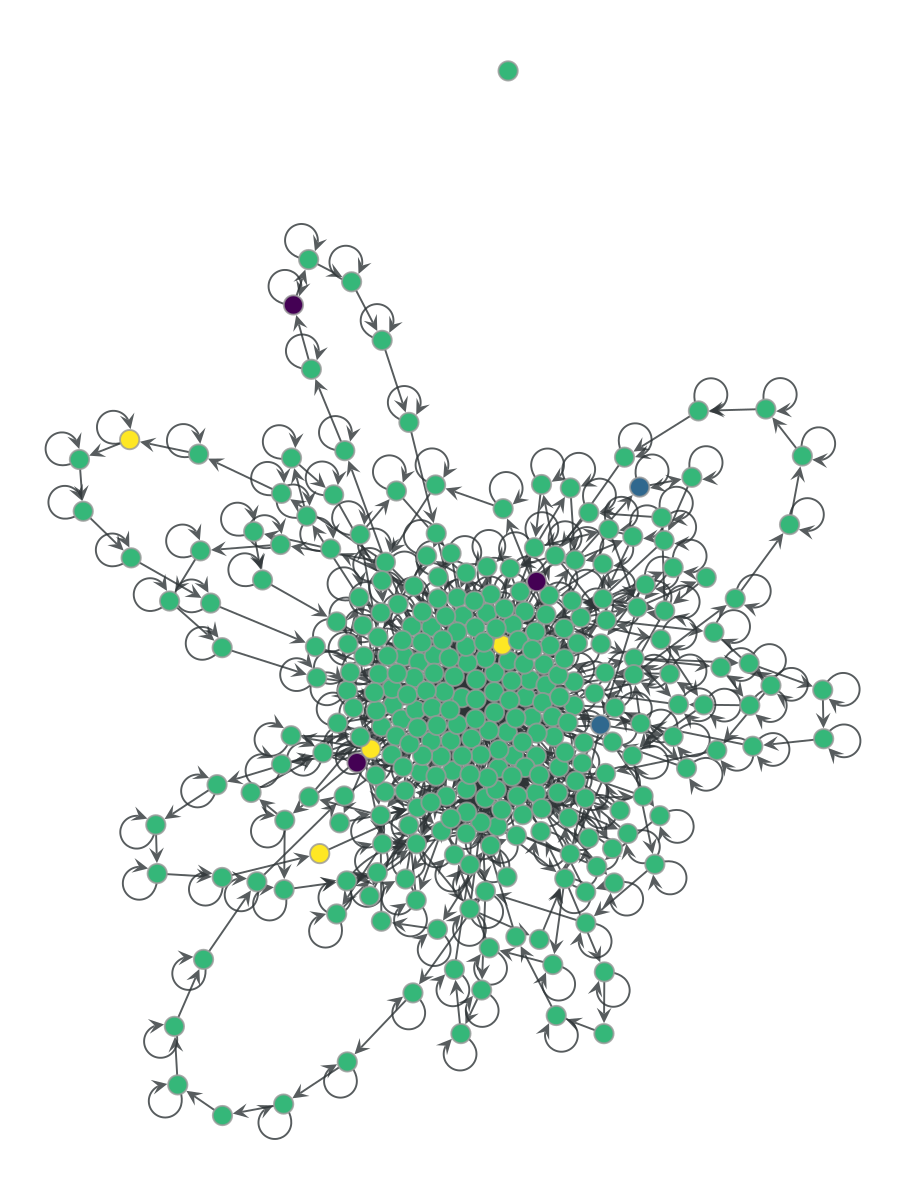

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f0b4bab92b0, at 0x7f0b4bd223c0>

In [9]:
graph_draw(g,# pos=pos, 
           #vertex_size=vsize, 
           vertex_fill_color=v_color, 
           #edge_pen_width=esize, edge_marker_size=7, 
           bg_color="w")#, output="images/graph_example.png")

In [15]:
state = minimize_blockmodel_dl(g)

In [28]:
state.get_blocks().a

PropertyArray([ 52,  51, 266, 169,   5,  52, 263, 263, 169,  51,  52,  51,
               226, 263, 266,  51, 266, 266, 169, 169, 263, 263, 266,  52,
                51, 169, 266, 226,  51,  51,  51, 169, 263, 266, 266, 266,
               266, 263, 169,  52, 169,  51, 226, 169, 226,  52,  51, 263,
               266,  52, 266,  52, 169, 226, 169,  52,  51, 169,  51, 169,
               266, 169, 169, 263,  51,  52, 226, 266,  52, 169, 266, 263,
               263,  52, 259, 169,  52, 169,  52, 169, 259,  52, 259, 169,
               226, 226, 169,  51, 169, 169,  52, 266, 263, 226, 169, 266,
               266, 263,  51, 169,  51,  51, 226, 169,  51, 259, 263, 226,
               263,  51,  52,  51, 263, 266, 169,  51,  52,  51, 266,  51,
               266, 169,  52, 169, 263, 266, 226, 259, 266,  52, 266, 266,
               169,  51, 259,  52, 263, 266, 169, 263, 259,  52, 263, 259,
               266, 169, 263, 169, 169,  52, 266,  51, 259,  51, 266,  51,
                51, 266, 

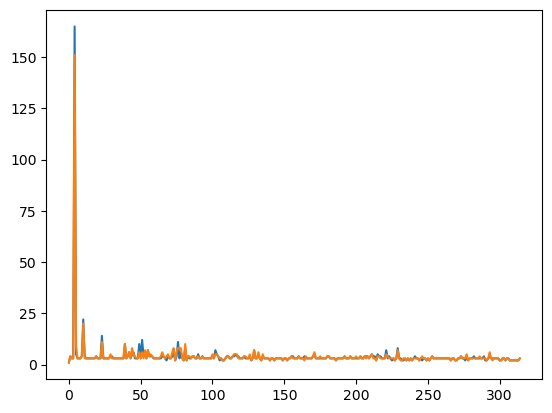

In [10]:
plt.plot(in_deg+1)
plt.plot(out_deg+1)
#plt.yscale('log')

In [11]:
state_df[np.isin(state_df['idx'], np.where(out_deg==0)[0])]

,idx,type,mut,nchr,ngenes


In [12]:
np.where(out_deg==0)

(array([0]),)

In [13]:
for a,b,c in zip(np.arange(1,len(out_deg)), in_deg[1:], out_deg[1:]):
    print(a,b,c)

1 3 3
2 2 2
3 2 2
4 164 150
5 4 8
6 2 2
7 2 2
8 2 2
9 3 3
10 21 19
11 3 2
12 2 2
13 2 2
14 2 2
15 2 2
16 2 2
17 2 2
18 2 2
19 3 3
20 2 2
21 2 2
22 2 2
23 13 10
24 2 2
25 2 2
26 2 2
27 2 2
28 2 2
29 3 4
30 3 2
31 2 2
32 2 2
33 2 2
34 2 2
35 2 2
36 2 2
37 2 2
38 2 2
39 9 9
40 2 2
41 3 3
42 5 5
43 2 2
44 4 7
45 5 4
46 2 3
47 2 2
48 2 2
49 9 5
50 2 2
51 11 5
52 3 2
53 4 6
54 2 2
55 6 6
56 3 3
57 3 4
58 3 3
59 2 2
60 2 2
61 2 2
62 2 2
63 2 2
64 2 3
65 3 5
66 3 3
67 2 2
68 1 3
69 3 4
70 2 2
71 2 2
72 3 5
73 5 7
74 1 1
75 3 5
76 10 7
77 2 7
78 5 7
79 2 2
80 1 1
81 7 9
82 1 1
83 3 3
84 2 3
85 2 2
86 3 3
87 3 3
88 2 2
89 2 2
90 4 3
91 2 2
92 2 2
93 3 3
94 2 2
95 2 2
96 2 2
97 2 2
98 2 2
99 2 2
100 3 4
101 2 2
102 6 4
103 4 4
104 3 3
105 1 2
106 2 2
107 1 1
108 1 1
109 2 2
110 3 3
111 3 3
112 2 2
113 2 2
114 3 3
115 3 4
116 4 4
117 3 4
118 3 2
119 2 2
120 2 2
121 2 2
122 3 3
123 2 3
124 2 2
125 2 2
126 3 4
127 1 1
128 2 2
129 6 6
130 2 2
131 2 2
132 4 5
133 2 2
134 1 1
135 3 4
136 2 2
137 2 2
13